# Analysing Air Pollution and Haze Patterns in [Country] Using Data Mining ⛏️

## Required Libraries and Depedencies

In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [40]:
%matplotlib inline

import pandas as pd

# Import helper functions from `src/utils.py`
from utils import assign_monsoon, compute_api_and_categories

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GridSearchCV, cross_validate

from sklearn.preprocessing import StandardScaler

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Chapter 3: Data Preprocessing

In [9]:
# Load the dataset
df = pd.read_parquet("./../data/air_pollution.parquet")

In [ ]:
# Convert date values into DateTime objects
df["date"] = pd.to_datetime(df["date"])

In [13]:
# Pivot from long form to wide form
df_pivot = df.pivot(
    index="date",
    columns="pollutant",
    values="concentration"
).reset_index() # Reset index instead of using "date" as the new index

In [14]:
# Temporal Filtering: Drop data before Jan 2018
df_final = df_pivot[
    (df_pivot["date"] >= "2018-01-01")
    & (df_pivot["date"] <= "2022-12-31")
].reset_index(
    drop=True
)

## Feature Engineering

In [15]:
# Particulate Ratio (PM 2.5/PM 10)
df_final["PM_Ratio"] = df_final["PM 2.5"]/df_final["PM 10"]

In [18]:
# API Score
df_final = compute_api_and_categories(df_final)

In [19]:
# Extract Month
df_final["Month"] = df_final["date"].dt.month

In [20]:
# Monsoon Season
df_final["Monsoon_Season"] = df_final["Month"].apply(assign_monsoon)

# One-Hot Encoding
df_encoded = pd.get_dummies(
    df_final,
    columns=["Monsoon_Season"],
    prefix="Monsoon",
    dtype=int,
    drop_first=False, # Retain all categories
)

In [21]:
# 1-month lag PM 2.5
df_encoded["PM25_lag1"] = df_encoded["PM 2.5"].shift(1)

df_encoded = df_encoded.dropna().reset_index(
    drop=True
) # Drop first row due to NaN lag

# Random Forest Regressor Model

Extract features and target. PM 10 and the particulate ratio are not included to avoid multicollinearity.

In [23]:
features = df_encoded[[
    "CO",
    "O3",
    "NO2",
    "SO2",
    'Monsoon_NE',
    'Monsoon_SW',
    'Monsoon_Inter_Monsoon',
    "PM25_lag1"
]]
target = df_encoded["PM 2.5"]

In [ ]:
# Create base rf_model
base_rf = RandomForestRegressor(random_state=10)

## Hyperparameter Tuning using GridSearchCV

In [ ]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 8, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 1.0],
}

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=10,
)

grid_search = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    cv=kf,
    scoring="r2",
    n_jobs=-1
)
grid_search.fit(features, target)

best_rf = grid_search.best_estimator_

print('=== Best Hyperparameters ===')
print(grid_search.best_params_)

=== Best Hyperparameters ===
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


## Evaluate Refined Model using k-fold Cross Validation

In [ ]:
cv_results = cross_validate(
    best_rf,
    features,
    target,
    cv=kf,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
    }
)

print('\n=== 5-Fold Cross-Validation Performance ===')
print(f"Mean R-squared: {np.mean(cv_results['test_r2']):.4f}")
print(f"Mean MAE: {-np.mean(cv_results['test_mae']):.4f}")
print(f"Mean RMSE: {-np.mean(cv_results['test_rmse']):.4f}")


=== 5-Fold Cross-Validation Performance ===
Mean R-squared: 0.4416
Mean MAE: 2.0092
Mean RMSE: 3.4257


## Feature Importance Chart

C:\Users\Admin\AppData\Local\Temp\ipykernel_33640\43905132.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


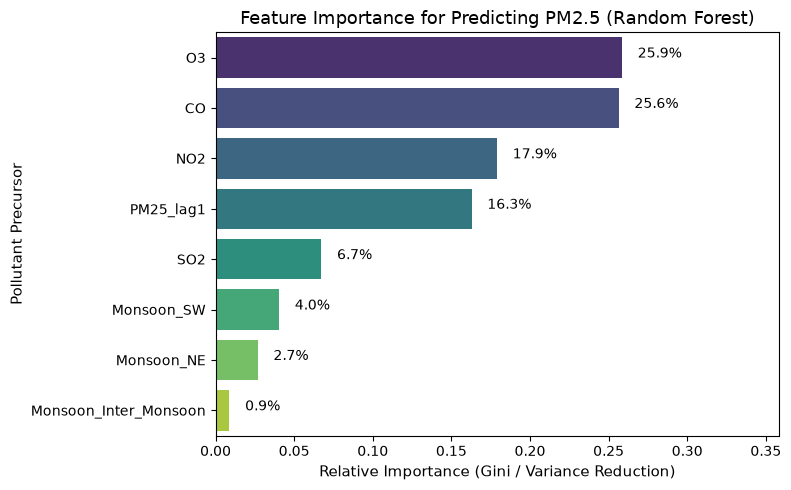

=== Feature Importance Values ===
              Feature  Importance
                   O3    0.258506
                   CO    0.256394
                  NO2    0.178999
            PM25_lag1    0.162839
                  SO2    0.067259
           Monsoon_SW    0.040404
           Monsoon_NE    0.026801
Monsoon_Inter_Monsoon    0.008798


In [32]:
importances = best_rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": features.columns,
    "Importance": importances
}).sort_values(
    by="Importance",
    ascending=False
)

plt.figure(
    figsize=(8, 5)
)

sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature",
    palette="viridis"
)

# Annotate bars with numeric percentage values
for index, value in enumerate(feature_importance_df["Importance"]):
    plt.text(
        value + 0.01,
        index,
        f"{value * 100:.1f}%",
    )

plt.title('Feature Importance for Predicting PM2.5 (Random Forest)', fontsize=13)
plt.xlabel('Relative Importance (Gini / Variance Reduction)', fontsize=11)
plt.ylabel('Pollutant Precursor', fontsize=11)
plt.xlim(0, max(feature_importance_df['Importance']) + 0.1)
plt.tight_layout()
plt.show()

# Exact tabular values for report
print("=== Feature Importance Values ===")
print(feature_importance_df.to_string(index=False))

# Chapter 2: Exploratory Data Analysis (EDA)

## Basic Overview

In [34]:
print("Final dataset shape: ", df.shape) # Expected: (60, 7) including "date"

Final dataset shape:  (432, 3)


In [35]:
print("\nInfo:")
df.info()


Info:
<class 'pandas.DataFrame'>
RangeIndex: 432 entries, 0 to 431
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           432 non-null    datetime64[ns]
 1   pollutant      432 non-null    object        
 2   concentration  410 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 10.3+ KB


In [36]:
print("\nSummary:")
print(df.describe(include="all"))


Summary:
                       date pollutant  concentration
count                   432       432     410.000000
unique                  NaN         6            NaN
top                     NaN        CO            NaN
freq                    NaN        72            NaN
mean    2019-12-16 11:20:00       NaN       6.349193
min     2017-01-01 00:00:00       NaN       0.000900
25%     2018-06-23 12:00:00       NaN       0.006600
50%     2019-12-16 12:00:00       NaN       0.020000
75%     2021-06-08 12:00:00       NaN      12.952500
max     2022-12-01 00:00:00       NaN      64.110000
std                     NaN       NaN      10.263692


## 1. Distribution of PM 2.5 Concentration (Histogram)

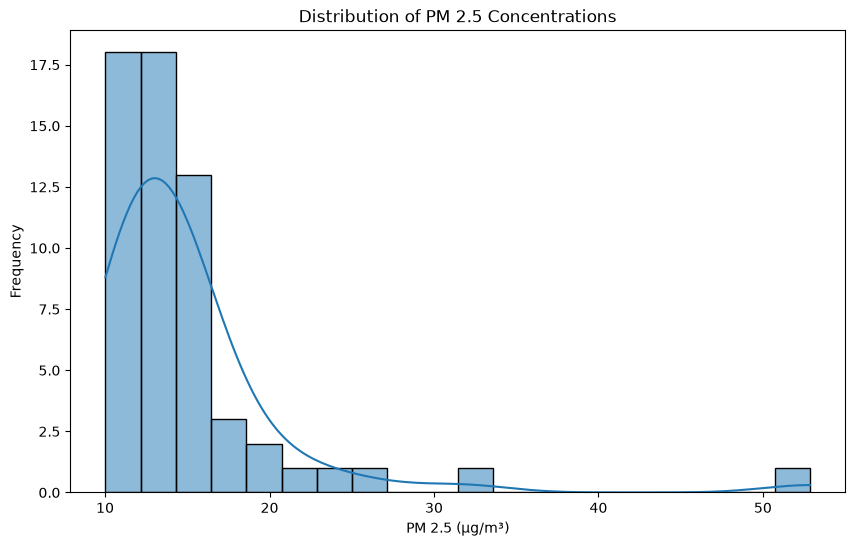

In [38]:
plt.figure(figsize=(10, 6))
sns.histplot(
    df_encoded['PM 2.5'],
    kde=True,
    bins=20
)
plt.title("Distribution of PM 2.5 Concentrations")
plt.xlabel("PM 2.5 (µg/m³)")
plt.ylabel("Frequency")
plt.show()

## 2. Standardized Boxplot of Pollutant Concentrations (Z-Score, 2018 - 2022)

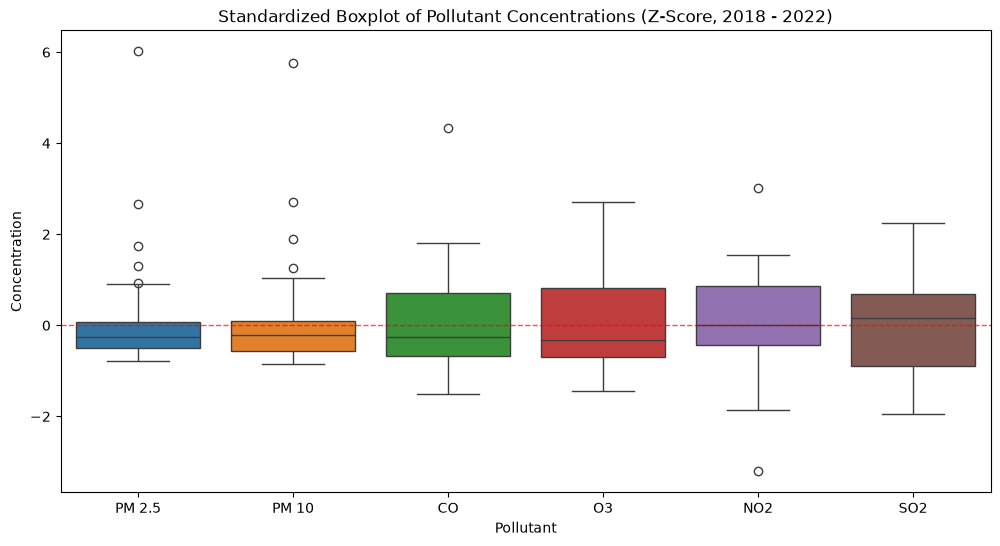

In [41]:
pollutant_cols = ["PM 2.5", "PM 10", "CO", "O3", "NO2", "SO2"]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(
    df_encoded[pollutant_cols]
)

df_scaled = pd.DataFrame(
    scaled_data,
    columns=[pollutant_cols]
)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_scaled
)
plt.title("Standardized Boxplot of Pollutant Concentrations (Z-Score, 2018 - 2022)")
plt.xlabel("Pollutant")
plt.ylabel("Concentration")
plt.axhline(
    0,
    color='red',
    linestyle='--',
    linewidth=1,
    alpha=0.7
)  # Mean baseline
plt.show()

## 3. Correlation Heatmap of Pollutants (2018 - 2022)

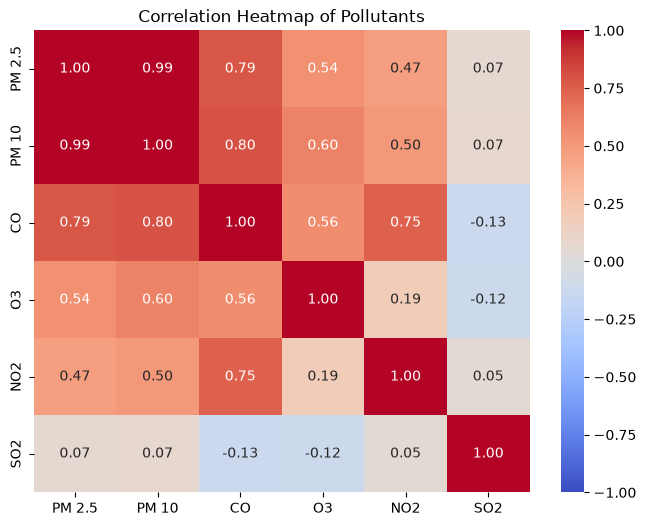

In [46]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_encoded[pollutant_cols].corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f", # format
    vmax=1.0,
    vmin=-1.0,
    center=0.0,
)
plt.title("Correlation Heatmap of Pollutants")
plt.show()

## 4. Trend of PM 2.5 Concentration Over Time (2018 - 2022)

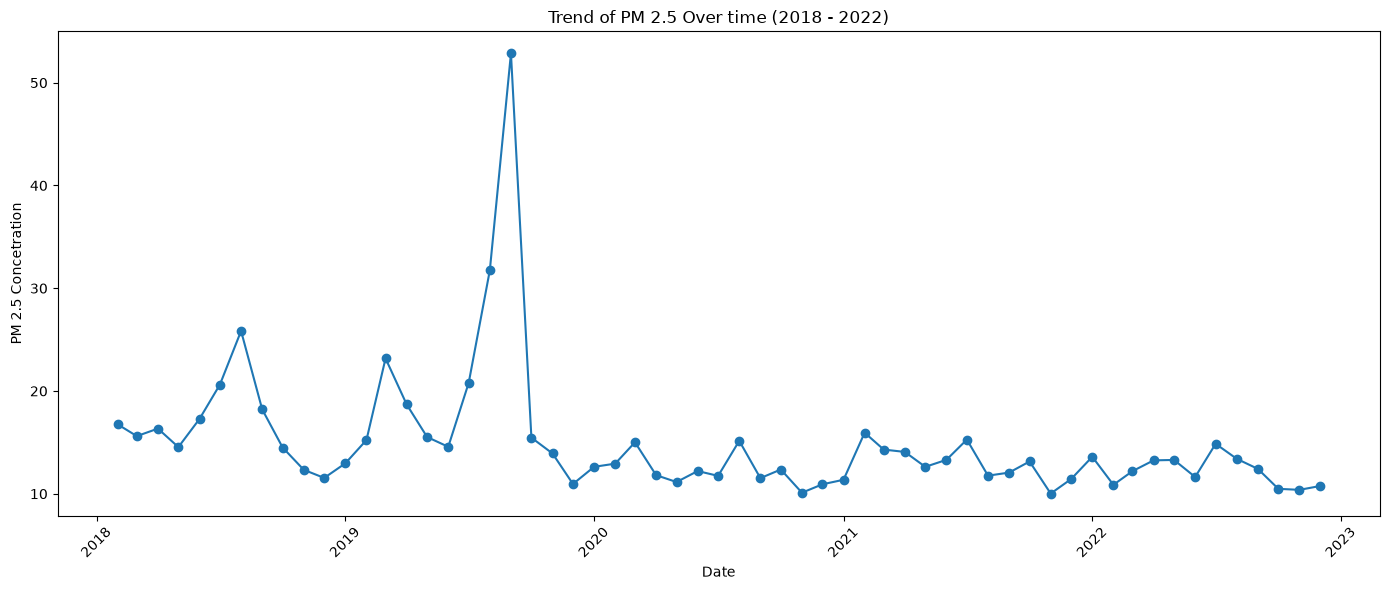

In [44]:
plt.figure(figsize=(14, 6))
plt.plot(
    df_encoded["date"],
    df_encoded["PM 2.5"],
    marker="o",
    linestyle="-"
)
plt.title("Trend of PM 2.5 Over time (2018 - 2022)")
plt.xlabel("Date")
plt.ylabel("PM 2.5 Concetration")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()